In [104]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

In [2]:
print(tf.__version__)

2.11.0-dev20220812


### Part 1: Read in the data

In [7]:
path=r'C:\Users\aleci\Documents\Project 6 - Credit Card Fraud Detection\data\\'

In [10]:
df=pd.read_csv(path+'creditcard.csv')

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [12]:
df.groupby('Class')['Time'].count()

Class
0    284315
1       492
Name: Time, dtype: int64

In [13]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [14]:
df.shape

(284807, 31)

### Part 2: Check data quality

In [15]:
# check null values
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

* No null values

In [18]:
# observations in each class
df['Class'].value_counts()

0    284315
1       492
Name: Class, dtype: int64

In [19]:
# balance the dataset
fraud=df[df['Class']==1]
non_fraud=df[df['Class']==0]

In [20]:
fraud.shape, non_fraud.shape

((492, 31), (284315, 31))

In [21]:
# random selection of samples
non_fraud_t=non_fraud.sample(n=492)

In [22]:
non_fraud_t.shape

(492, 31)

In [23]:
# merge the dataset
dataset=fraud.append(non_fraud_t, ignore_index=True)

In [24]:
print(dataset)

         Time        V1        V2        V3        V4        V5        V6  \
0       406.0 -2.312227  1.951992 -1.609851  3.997906 -0.522188 -1.426545   
1       472.0 -3.043541 -3.157307  1.088463  2.288644  1.359805 -1.064823   
2      4462.0 -2.303350  1.759247 -0.359745  2.330243 -0.821628 -0.075788   
3      6986.0 -4.397974  1.358367 -2.592844  2.679787 -1.128131 -1.706536   
4      7519.0  1.234235  3.019740 -4.304597  4.732795  3.624201 -1.357746   
..        ...       ...       ...       ...       ...       ...       ...   
979  123375.0  2.366161 -1.418134 -1.481920 -1.936175 -0.604947  0.230234   
980  145156.0  2.058899 -0.067187 -1.131665  0.386329 -0.067009 -1.123728   
981  150259.0 -0.866013  1.661365 -0.512469 -0.940103  0.719244  0.115590   
982  153868.0  2.031695  0.173970 -1.740215  0.532549  0.182197 -1.482105   
983   54148.0  0.216477 -2.390834  1.174367  1.467392 -2.046394  1.140016   

           V7        V8        V9  ...       V21       V22       V23  \
0  

In [25]:
dataset['Class'].value_counts()

1    492
0    492
Name: Class, dtype: int64

In [26]:
# matrix of features
x=dataset.drop(labels=['Class'], axis=1)

In [27]:
# dependent variable
y=dataset['Class']

In [28]:
x.shape, y.shape

((984, 30), (984,))

In [35]:
# split the sample into train and test sets
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test=train_test_split(x, y, test_size=0.2, random_state=0)

In [36]:
x_train.shape, x_test.shape

((787, 30), (197, 30))

In [37]:
# feature scaling
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
x_train=sc.fit_transform(x_train)
x_test=sc.transform(x_test)

In [38]:
x_train

array([[ 1.62341572,  0.4659244 , -0.35895103, ..., -0.00547024,
         0.04642994, -0.40415228],
       [-0.77985982,  0.51849331, -0.07750654, ...,  0.47197425,
         0.63071299, -0.44126512],
       [-0.8165855 ,  0.1970432 ,  0.11631439, ...,  0.30862175,
         0.47483454, -0.44030011],
       ...,
       [-0.89962197,  0.27685594, -0.67220395, ..., -0.31127624,
        -0.19488425, -0.40431311],
       [-0.91287137,  0.67277274, -0.78002176, ..., -0.16477824,
        -0.06458442, -0.0643466 ],
       [-0.41868946,  0.29470234, -0.36632352, ..., -0.16109906,
         0.14220966, -0.39808073]])

In [39]:
y_train=y_train.to_numpy()
y_test=y_test.to_numpy()

In [41]:
x_train.shape, x_test.shape

((787, 30), (197, 30))

In [42]:
# reshape the dataset
x_train=x_train.reshape(787, 30, 1)
x_test=x_test.reshape(197, 30, 1)

In [43]:
x_train.shape, x_test.shape

((787, 30, 1), (197, 30, 1))

### Part 3: set up the model structure

In [57]:
# define an object for the model
model=tf.keras.models.Sequential()

In [58]:
# 1st CNN layer
model.add(tf.keras.layers.Conv1D(filters=32, kernel_size=2, padding='same', activation='relu', input_shape=(30, 1)))

# batch normalization 
model.add(tf.keras.layers.BatchNormalization())

# maxpool layer
model.add(tf.keras.layers.MaxPool1D(pool_size=2))

# dropout layer
model.add(tf.keras.layers.Dropout(0.2))

# 2nd CNN layer
model.add(tf.keras.layers.Conv1D(filters=64, kernel_size=2, padding='same', activation='relu'))

# batch normalization 
model.add(tf.keras.layers.BatchNormalization())

# maxpool layer
model.add(tf.keras.layers.MaxPool1D(pool_size=2))

# dropout layer
model.add(tf.keras.layers.Dropout(0.3))


In [59]:
# flatten layer
model.add(tf.keras.layers.Flatten())

In [60]:
# first dense layer
model.add(tf.keras.layers.Dense(units=64, activation='relu'))

# dropout layer
model.add(tf.keras.layers.Dropout(0.3))

In [62]:
# output layer
model.add(tf.keras.layers.Dense(units=1, activation='sigmoid'))

In [63]:
model.summary()

Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv1d_6 (Conv1D)           (None, 30, 32)            96        
                                                                 
 batch_normalization_6 (Batc  (None, 30, 32)           128       
 hNormalization)                                                 
                                                                 
 max_pooling1d_6 (MaxPooling  (None, 15, 32)           0         
 1D)                                                             
                                                                 
 dropout_3 (Dropout)         (None, 15, 32)            0         
                                                                 
 conv1d_7 (Conv1D)           (None, 15, 64)            4160      
                                                                 
 batch_normalization_7 (Batc  (None, 15, 64)          

In [64]:
opt=tf.keras.optimizers.Adam(learning_rate=0.0001)

In [65]:
# compile the model
model.compile(optimizer=opt, loss='binary_crossentropy', metrics=['accuracy'])

### Part 4: Compile the model

In [67]:
history=model.fit(x_train, y_train, epochs=25, validation_data=(x_test, y_test))

Epoch 1/25
25/25 [==============================] - 2s 19ms/step - loss: 1.0158 - accuracy: 0.5997 - val_loss: 0.6316 - val_accuracy: 0.6701
Epoch 2/25
25/25 [==============================] - 0s 7ms/step - loss: 0.7161 - accuracy: 0.7065 - val_loss: 0.5932 - val_accuracy: 0.7970
Epoch 3/25
25/25 [==============================] - 0s 7ms/step - loss: 0.6088 - accuracy: 0.7637 - val_loss: 0.5580 - val_accuracy: 0.8426
Epoch 4/25
25/25 [==============================] - 0s 7ms/step - loss: 0.4963 - accuracy: 0.8043 - val_loss: 0.5160 - val_accuracy: 0.8629
Epoch 5/25
25/25 [==============================] - 0s 7ms/step - loss: 0.4428 - accuracy: 0.8196 - val_loss: 0.4750 - val_accuracy: 0.8680
Epoch 6/25
25/25 [==============================] - 0s 9ms/step - loss: 0.4084 - accuracy: 0.8259 - val_loss: 0.4375 - val_accuracy: 0.8680
Epoch 7/25
25/25 [==============================] - 0s 7ms/step - loss: 0.3933 - accuracy: 0.8602 - val_loss: 0.3996 - val_accuracy: 0.8934
Epoch 8/25
25/25 [=

In [79]:
# model predictions
y_pred=model.predict(x_test)
classes_y=np.argmax(y_pred, axis=1)



7/7 [==============================] - 0s 3ms/step


In [80]:
print(y_pred[0], classes_y[0], y_test[0])

[0.06546193] 0 1


In [81]:
from sklearn.metrics import confusion_matrix, accuracy_score
cm=confusion_matrix(y_test, classes_y)
print(cm)

[[106   0]
 [ 91   0]]


In [84]:
acc_cm=accuracy_score(y_test, classes_y)
print(acc_cm)

0.5380710659898477


In [85]:
# Learning curve
def learning_curve(history, epoch):
    # training vs validation accuracy
    epoch_range=range(1, epoch+1)
    plt.plot(epoch_range, history.history['accuracy'])
    plt.plot(epoch_range, history.history['val_accuracy'])
    plt.title('Model Accuracy')
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend(['Training', 'Validation'], loc='upper left')
    plt.show()
    

    # training vs validation loss
    epoch_range=range(1, epoch+1)
    plt.plot(epoch_range, history.history['loss'])
    plt.plot(epoch_range, history.history['val_loss'])
    plt.title('LOss')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend(['Training', 'Validation'], loc='upper left')
    plt.show()

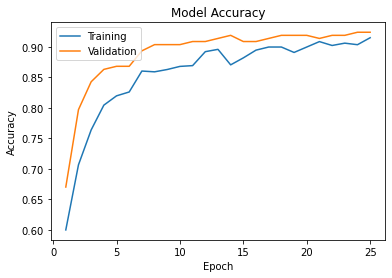

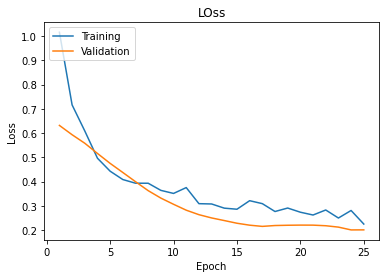

In [87]:
learning_curve(history, 25)

In [98]:
y_pred_df=pd.DataFrame(y_pred)
y_pred_df.columns=['y_pred']

In [99]:
y_test_df=pd.DataFrame(y_test)
y_test_df.columns=['y']

In [100]:
y_test_df['y_pred']=y_pred_df

In [101]:
y_test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 197 entries, 0 to 196
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   y       197 non-null    int64  
 1   y_pred  197 non-null    float32
dtypes: float32(1), int64(1)
memory usage: 2.4 KB


In [106]:
num_bins=10

binlabels=list(range(0, num_bins))

y_test_df['score_cut']=pd.qcut(y_test_df['y_pred'], q=num_bins, labels=binlabels)

C:\Users\aleci\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


<AxesSubplot:xlabel='score_cut', ylabel='y'>

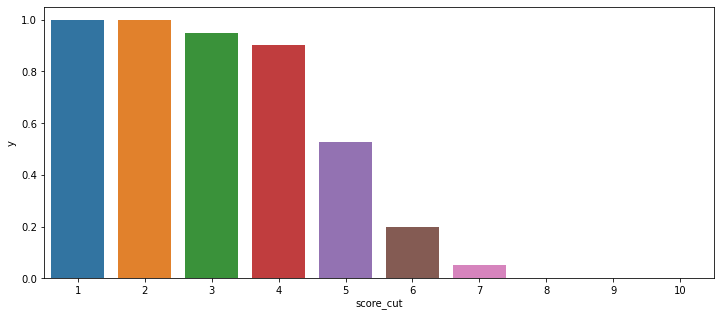

In [107]:
fig=plt.figure(figsize=(12, 5))

y_test_df_sum=y_test_df.groupby('score_cut')[['y_pred', 'y']].mean().reset_index()
y_test_df_sum['score_cut']=y_test_df_sum['score_cut'].astype(int)
y_test_df_sum['score_cut']=num_bins-y_test_df_sum['score_cut']

sns.barplot(y_test_df_sum['score_cut'], y_test_df_sum['y'])

Text(0, 0.5, 'Predicted/Actual')

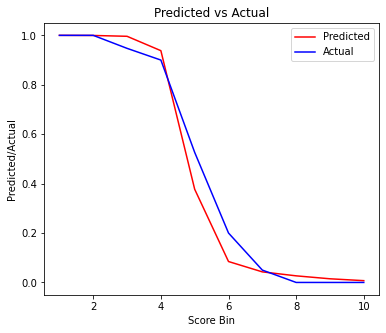

In [108]:
fig, ax=plt.subplots(1, 1, figsize=(6, 5))

ax.plot(y_test_df_sum['score_cut'], y_test_df_sum['y_pred'], label='Predicted', color='red')
ax.plot(y_test_df_sum['score_cut'], y_test_df_sum['y'], label='Actual', color='blue')
ax.set_title('Predicted vs Actual')
ax.legend(loc='upper right')
ax.set_xlabel('Score Bin')
ax.set_ylabel('Predicted/Actual')